In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [76]:
df=pd.read_csv('Food_Delivery_Times.csv')

In [77]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [79]:
print('Missing values per column:')
display(df.isnull().sum())

Missing values per column:


,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [80]:
df.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [81]:
# Fill missing values for categorical columns with their mode
for col in ['Weather', 'Traffic_Level', 'Time_of_Day']:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)

# Fill missing values for Courier_Experience_yrs with its median
median_experience = df['Courier_Experience_yrs'].median()
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(median_experience)

# Drop the Order_ID column
df = df.drop(columns=['Order_ID'])

# Verify that cleaning was successful
print('Remaining null values:')
print(df.isnull().sum())
display(df.head())

Remaining null values:
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64


,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68


### 1. Target Variable Distribution
Let's visualize how `Delivery_Time_min` is distributed across our dataset.

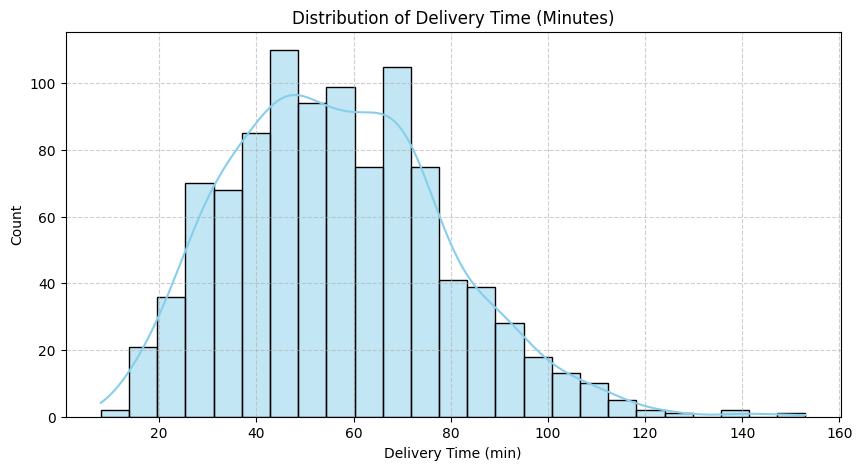

In [82]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Delivery_Time_min'], kde=True, color='skyblue')
plt.title('Distribution of Delivery Time (Minutes)')
plt.xlabel('Delivery Time (min)')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 2. Numerical Features vs. Target Variable
Let's plot scatter plots and calculate correlations to understand how `Distance_km`, `Preparation_Time_min`, and `Courier_Experience_yrs` relate to `Delivery_Time_min`.

Correlation Matrix:


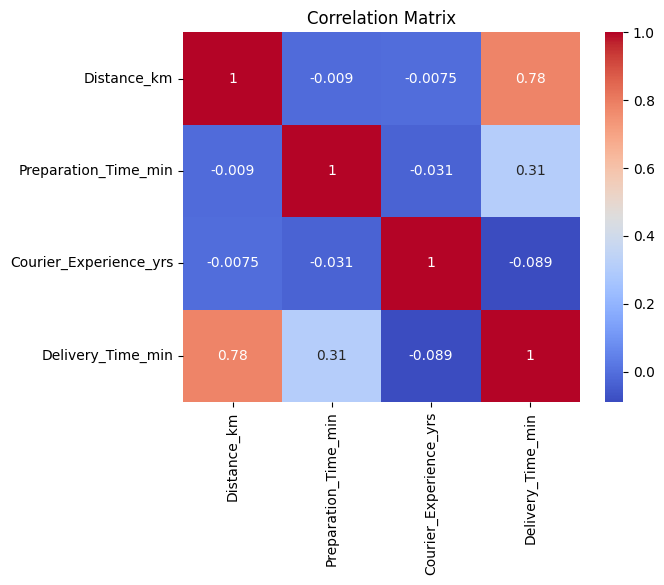

In [83]:
# Display numerical correlation with Delivery_Time_min
numerical_cols = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']
print("Correlation Matrix:")
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

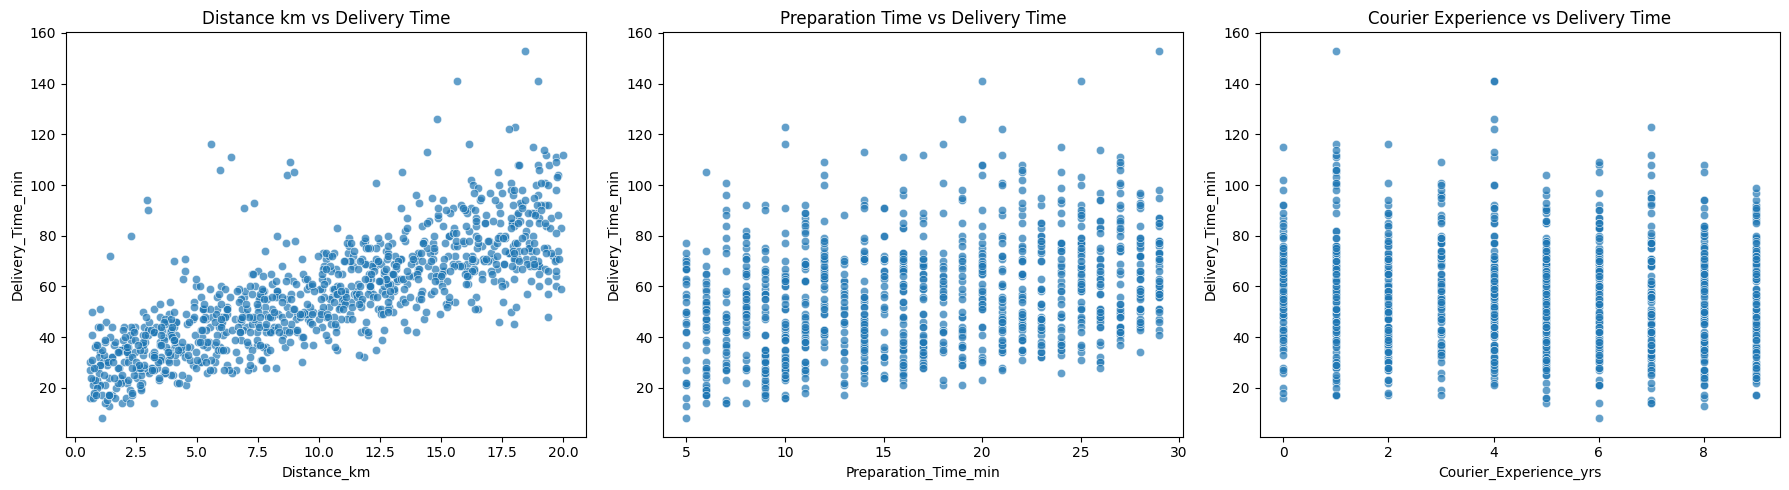

In [84]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distance vs Delivery Time
sns.scatterplot(data=df, x='Distance_km', y='Delivery_Time_min', ax=axes[0], alpha=0.7)
axes[0].set_title('Distance km vs Delivery Time')

# Preparation Time vs Delivery Time
sns.scatterplot(data=df, x='Preparation_Time_min', y='Delivery_Time_min', ax=axes[1], alpha=0.7)
axes[1].set_title('Preparation Time vs Delivery Time')

# Courier Experience vs Delivery Time
sns.scatterplot(data=df, x='Courier_Experience_yrs', y='Delivery_Time_min', ax=axes[2], alpha=0.7)
axes[2].set_title('Courier Experience vs Delivery Time')

plt.tight_layout()
plt.show()



### 3. Categorical Features vs. Target Variable
Let's see how different factors like `Weather`, `Traffic_Level`, `Time_of_Day`, and `Vehicle_Type` impact the delivery time.

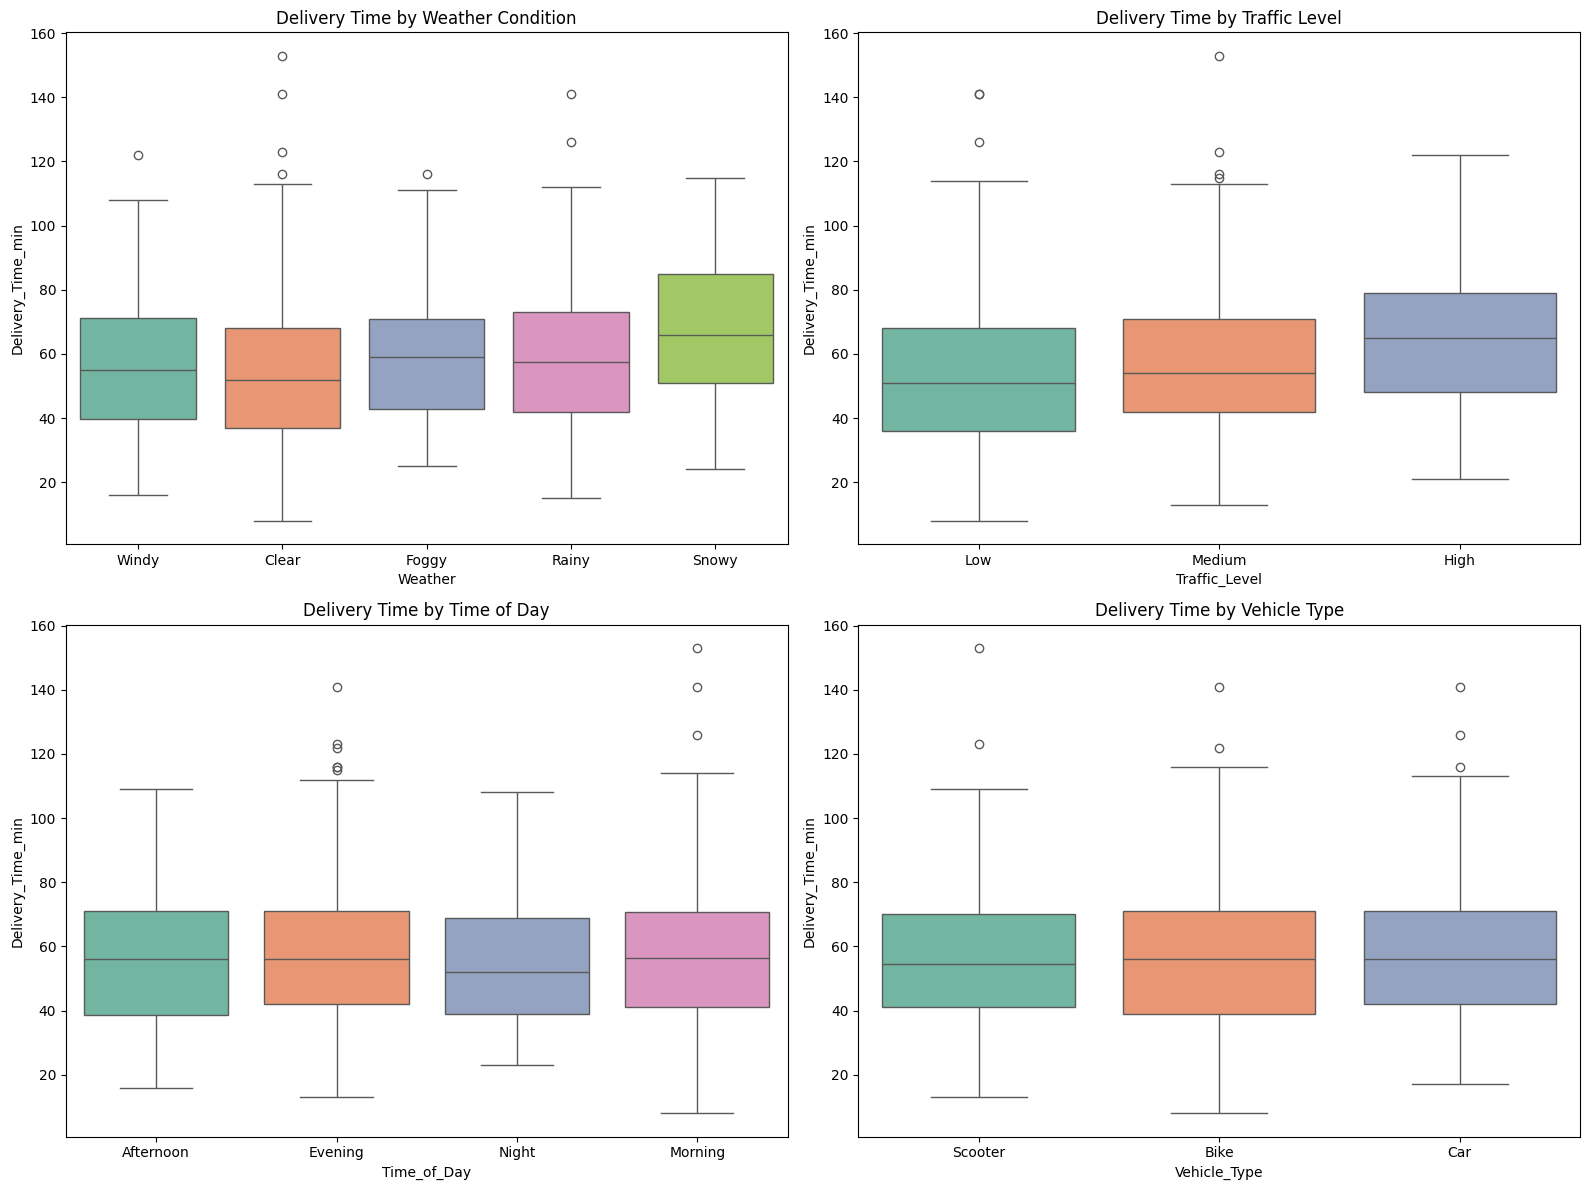

In [85]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot(data=df, x='Weather', y='Delivery_Time_min', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Delivery Time by Weather Condition')

sns.boxplot(data=df, x='Traffic_Level', y='Delivery_Time_min', ax=axes[0, 1], palette='Set2',
            order=['Low', 'Medium', 'High'])
axes[0, 1].set_title('Delivery Time by Traffic Level')

sns.boxplot(data=df, x='Time_of_Day', y='Delivery_Time_min', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Delivery Time by Time of Day')

sns.boxplot(data=df, x='Vehicle_Type', y='Delivery_Time_min', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Delivery Time by Vehicle Type')

plt.tight_layout()
plt.show()

### Statistical Testing for Feature Selection
Let's analyze the statistical significance of both numerical and categorical features relative to our target `Delivery_Time_min`.

In [86]:
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

print("=== 1. Statistical Significance of Numerical Features (Correlation Test) ===")
numerical_cols = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']
for col in numerical_cols:
    corr, p_val = stats.pearsonr(df[col], df['Delivery_Time_min'])
    print(f"{col:25} -> Correlation: {corr:6.3f} | P-value: {p_val:.3e} ({'Significant' if p_val < 0.05 else 'Not Significant'})")

print("\n=== 2. Statistical Significance of Categorical Features (ANOVA Test) ===")
categorical_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
for col in categorical_cols:
    # Fit ANOVA model
    model = ols(f'Delivery_Time_min ~ C({col})', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    p_val = anova_table["PR(>F)"][0]
    f_stat = anova_table["F"][0]
    print(f"{col:25} -> F-statistic: {f_stat:6.2f} | P-value: {p_val:.3e} ({'Significant' if p_val < 0.05 else 'Not Significant'})")

=== 1. Statistical Significance of Numerical Features (Correlation Test) ===
Distance_km               -> Correlation:  0.781 | P-value: 2.976e-206 (Significant)
Preparation_Time_min      -> Correlation:  0.307 | P-value: 2.550e-23 (Significant)
Courier_Experience_yrs    -> Correlation: -0.089 | P-value: 4.802e-03 (Significant)

=== 2. Statistical Significance of Categorical Features (ANOVA Test) ===
Weather                   -> F-statistic:  10.50 | P-value: 2.472e-08 (Significant)
Traffic_Level             -> F-statistic:  19.75 | P-value: 3.870e-09 (Significant)
Time_of_Day               -> F-statistic:   0.35 | P-value: 7.915e-01 (Not Significant)
Vehicle_Type              -> F-statistic:   0.59 | P-value: 5.549e-01 (Not Significant)


### Executive Summary: Key Feature Insights

Based on our Exploratory Data Analysis (EDA) and rigorous statistical testing, we can categorize our features into **Highly Significant**, **Slightly Significant**, and **Non-Significant** predictors for our target variable, `Delivery_Time_min`:

#### 1. Highly Significant Features (Strong Predictors)
*   **`Distance_km`** (Pearson Correlation: **0.781**, p-value: ~0.0):
    *   *Insight:* This is the strongest predictor of delivery times. As distance increases, the delivery time increases linearly.
*   **`Traffic_Level`** (ANOVA F-statistic: **19.75**, p-value: $3.87 \times 10^{-9}$):
    *   *Insight:* Traffic conditions significantly affect delivery times. High traffic heavily delays couriers.
*   **`Weather`** (ANOVA F-statistic: **10.50**, p-value: $2.47 \times 10^{-8}$):
    *   *Insight:* Adverse weather conditions (such as Rain, Fog, or Wind) lead to significantly longer delivery times compared to clear days.
*   **`Preparation_Time_min`** (Pearson Correlation: **0.307**, p-value: $2.55 \times 10^{-23}$):
    *   *Insight:* Food preparation times have a moderate positive correlation with final delivery time, as longer kitchen prep delays the courier departure.

#### 2. Weakly/Slightly Significant Features
*   **`Courier_Experience_yrs`** (Pearson Correlation: **-0.089**, p-value: $0.0048$):
    *   *Insight:* There is a statistically significant, but very weak negative correlation. Experienced couriers tend to complete deliveries slightly faster, but experience alone is not a primary driver of delivery speed.

#### 3. Non-Significant Features (Can be safely dropped during modeling)
*   **`Time_of_Day`** (ANOVA F-statistic: **0.35**, p-value: $0.792$):
    *   *Insight:* The delivery times remain consistently distributed regardless of whether it is Morning, Afternoon, Evening, or Night.
*   **`Vehicle_Type`** (ANOVA F-statistic: **0.59**, p-value: $0.555$):
    *   *Insight:* The choice of vehicle (Scooter, Bike, etc.) does not show a statistically significant effect on overall delivery speed.

---
*Recommendation: For building predictive machine learning models, focus heavily on **Distance_km**, **Traffic_Level**, **Weather**, and **Preparation_Time_min**.*

In [87]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Initialize LabelEncoder
le = LabelEncoder()

# Identify categorical columns
categorical_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

# Apply LabelEncoder to each categorical column
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Display the encoded DataFrame to confirm
display(df.head())

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,4,1,0,2,12,1.0,43
1,16.42,0,2,1,0,20,2.0,84
2,9.52,1,1,3,2,28,1.0,59
3,7.44,2,2,0,2,5,1.0,37
4,19.03,0,1,2,0,16,5.0,68


In [88]:
# Define features (X) and target (y)
X = df.drop(columns=['Delivery_Time_min'])
y = df['Delivery_Time_min']

# Perform train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the splits
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (800, 7)
X_test shape: (200, 7)
y_train shape: (800,)
y_test shape: (200,)


In [89]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Initialize the Decision Tree Regressor with default parameters
dt_model = DecisionTreeRegressor(random_state=42)

# Fit the model on the training data
dt_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = dt_model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Output model evaluation results
print("=== Decision Tree Regressor (Default Parameters) ===")
print(f"Mean Absolute Error (MAE): {mae:.2f} minutes")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} minutes")
print(f"R-squared (R2 Score): {r2:.4f}")

=== Decision Tree Regressor (Default Parameters) ===
Mean Absolute Error (MAE): 10.56 minutes
Mean Squared Error (MSE): 226.82
Root Mean Squared Error (RMSE): 15.06 minutes
R-squared (R2 Score): 0.4940


In [90]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor with default parameters
rf_model = RandomForestRegressor(random_state=42)

# Fit the model on the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Calculate evaluation metrics
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Output model evaluation results
print("=== Random Forest Regressor (Default Parameters) ===")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f} minutes")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f} minutes")
print(f"R-squared (R2 Score): {r2_rf:.4f}")

=== Random Forest Regressor (Default Parameters) ===
Mean Absolute Error (MAE): 7.06 minutes
Mean Squared Error (MSE): 100.12
Root Mean Squared Error (RMSE): 10.01 minutes
R-squared (R2 Score): 0.7766


### 1. Hyperparameter Tuning using `RandomizedSearchCV`

Rather than searching every possible combination exhaustively, we use **Random Search CV** (`RandomizedSearchCV`). This randomly samples a specified number of parameter combinations (`n_iter=50`) from a distribution, which is significantly faster and often performs just as well as Grid Search.

We define a parameter search space for the Random Forest model:
*   `n_estimators`: The number of trees in the forest (sampled between 100 and 500).
*   `max_depth`: The maximum depth of each tree (helps control overfitting).
*   `min_samples_split`: The minimum number of samples required to split an internal node.
*   `min_samples_leaf`: The minimum number of samples required to be at a leaf node.
*   `max_features`: The number of features to consider when looking for the best split.

In [91]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Define the parameter distribution to sample from
param_distributions = {
    'n_estimators': randint(100,1001),
    'max_depth': randint(5, 31),
    'min_samples_split': randint(2, 21),
    'min_samples_leaf': randint(1, 11),
    'max_features': ['sqrt', 'log2', None]
}

# Initialize the Random Forest Regressor
rf = RandomForestRegressor(random_state=42)

# Set up Randomized Search with 5-fold cross-validation
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit the random search to the training data
random_search.fit(X_train, y_train)

# Get the best estimator and parameters
best_rf_model = random_search.best_estimator_
best_params = random_search.best_params_

print("=== Best Hyperparameters found via Random Search ===")
for param, val in best_params.items():
    print(f"{param}: {val}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
=== Best Hyperparameters found via Random Search ===
max_depth: 26
max_features: None
min_samples_leaf: 5
min_samples_split: 2
n_estimators: 484


### 3. Final Model Evaluation with Best Hyperparameters

Now, we will train our final `RandomForestRegressor` using the optimal parameters discovered during the hyperparameter tuning phase.

In [93]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Initialize the Random Forest model with the best selected hyperparameters
optimized_rf = RandomForestRegressor(
    n_estimators=484,
    max_depth=26,
    min_samples_split=2,
    min_samples_leaf=5,
    max_features=None,
    random_state=42
)

# Train the optimized model
optimized_rf.fit(X_train, y_train)

# Predict on the test set
y_pred_opt = optimized_rf.predict(X_test)

# Calculate evaluation metrics
mse_opt = mean_squared_error(y_test, y_pred_opt)
rmse_opt = np.sqrt(mse_opt)
mae_opt = mean_absolute_error(y_test, y_pred_opt)
r2_opt = r2_score(y_test, y_pred_opt)

# Display the final performance
print("=== Optimized Random Forest Regressor Performance ===")
print(f"Mean Absolute Error (MAE): {mae_opt:.2f} minutes")
print(f"Mean Squared Error (MSE): {mse_opt:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_opt:.2f} minutes")
print(f"R-squared (R2 Score): {r2_opt:.4f}")

=== Optimized Random Forest Regressor Performance ===
Mean Absolute Error (MAE): 6.91 minutes
Mean Squared Error (MSE): 98.33
Root Mean Squared Error (RMSE): 9.92 minutes
R-squared (R2 Score): 0.7806


### 4. Exporting Model and Encoders for Deployment

To build a front-end application (e.g., using Streamlit, Flask, or FastAPI), we need to save the trained model and the label encoding configurations. We will export both of them as serialized binary `.pkl` files using Python's `pickle` library.

In [94]:
import pickle
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. Re-fitting individual LabelEncoders to store them collectively
# This ensures you can map category strings to numeric values in your frontend app
encoders_dict = {}
categorical_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

# We reload the raw dataset once to fit the encoders correctly from raw string categories
raw_df = pd.read_csv('Food_Delivery_Times.csv')
for col in categorical_cols:
    # Clean missing values matching our preprocessing pipeline
    mode_val = raw_df[col].mode()[0]
    raw_df[col] = raw_df[col].fillna(mode_val)

    # Fit the LabelEncoder
    le_col = LabelEncoder()
    le_col.fit(raw_df[col])
    encoders_dict[col] = le_col

# 2. Save the Encoders dictionary to a pickle file
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(encoders_dict, f)

# 3. Save the Optimized Random Forest Model to a pickle file
with open('best_random_forest_model.pkl', 'wb') as f:
    pickle.dump(optimized_rf, f)

print("=== Export Successful ===")
print("1. Saved 'label_encoders.pkl' containing fitted LabelEncoders for Web/App application.")
print("2. Saved 'best_random_forest_model.pkl' containing your trained predictive model.")

=== Export Successful ===
1. Saved 'label_encoders.pkl' containing fitted LabelEncoders for Web/App application.
2. Saved 'best_random_forest_model.pkl' containing your trained predictive model.
